In [8]:
# ============================================================
# İSTANBUL 39 İLÇE SU TÜKETİM TAHMİNİ - CHRONOS
# Konut ve işyeri ayrı ayrı tahmin edilir, sonra toplanır
# Eğitim: 2020-01 → 2024-12  |  Tahmin: 2025-01 → 2025-12
# Model: amazon/chronos-t5-large (Hugging Face)
# ============================================================

# ── AŞAMA 1: KÜTÜPHANELERİ İÇE AKTAR ──────────────────────
# Kurulum (ilk çalıştırmadan önce terminalde çalıştır):
#   pip install chronos-forecasting
#   pip install torch

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import torch
from chronos import ChronosPipeline

print("✅ Kütüphaneler yüklendi")
print(f"   PyTorch : {torch.__version__}")
print(f"   CUDA    : {torch.cuda.is_available()}")

✅ Kütüphaneler yüklendi
   PyTorch : 2.12.0+cpu
   CUDA    : False


In [9]:
# ── AŞAMA 2: DOSYA YOLLARI ─────────────────────────────────
ABONE_DOSYA    = r"C:\Users\mynet\OneDrive\Masaüstü\Bitirme Projesi\Veriler\abone.xlsx"
SU_DOSYA       = r"C:\Users\mynet\OneDrive\Masaüstü\Bitirme Projesi\Veriler\su_tuketim.xlsx"
SICAKLIK_DOSYA = r"C:\Users\mynet\OneDrive\Masaüstü\Bitirme Projesi\Veriler\sicaklik.xlsx"

In [10]:
# ── AŞAMA 3: YARDIMCI FONKSİYON - TARİH PARSE ─────────────
AYLAR_TR = {
    "Ocak":1, "Şubat":2, "Mart":3, "Nisan":4,
    "Mayıs":5, "Haziran":6, "Temmuz":7, "Ağustos":8,
    "Eylül":9, "Ekim":10, "Kasım":11, "Aralık":12
}

def tarih_parse(tarih_str):
    parcalar = str(tarih_str).strip().split()
    yil = int(parcalar[0])
    ay  = AYLAR_TR[parcalar[-1]]
    return pd.Timestamp(year=yil, month=ay, day=1)

In [11]:
# ── AŞAMA 4: ABONE VERİSİNİ YÜKLE ──────────────────────────
abone_raw = pd.read_excel(ABONE_DOSYA, header=1)

konut = abone_raw.iloc[:, 0:3].copy()
konut.columns = ["ilce", "tarih", "konut_abone"]

isyeri = abone_raw.iloc[:, 8:11].copy()
isyeri.columns = ["ilce", "tarih", "isyeri_abone"]

konut  = konut.dropna(subset=["ilce", "tarih"]).reset_index(drop=True)
isyeri = isyeri.dropna(subset=["ilce", "tarih"]).reset_index(drop=True)

konut["tarih"]  = konut["tarih"].apply(tarih_parse)
isyeri["tarih"] = isyeri["tarih"].apply(tarih_parse)

abone_df = pd.merge(konut, isyeri, on=["ilce", "tarih"], how="outer")
abone_df = abone_df[["ilce", "tarih", "konut_abone", "isyeri_abone"]]

print(f"✅ Abone verisi: {abone_df.shape[0]} satır, {abone_df['ilce'].nunique()} ilçe")

✅ Abone verisi: 2808 satır, 39 ilçe


In [12]:
# ── AŞAMA 5: SU TÜKETİM VERİSİNİ YÜKLE ────────────────────
su_raw = pd.read_excel(SU_DOSYA, header=1)

konut_su = su_raw.iloc[:, 0:3].copy()
konut_su.columns = ["ilce", "tarih", "konut_m3"]

isyeri_su = su_raw.iloc[:, 4:7].copy()
isyeri_su.columns = ["ilce", "tarih", "isyeri_m3"]

konut_su  = konut_su.dropna(subset=["ilce", "tarih"]).reset_index(drop=True)
isyeri_su = isyeri_su.dropna(subset=["ilce", "tarih"]).reset_index(drop=True)

konut_su["tarih"]  = konut_su["tarih"].apply(tarih_parse)
isyeri_su["tarih"] = isyeri_su["tarih"].apply(tarih_parse)

konut_su["konut_m3"]   = pd.to_numeric(konut_su["konut_m3"],   errors="coerce")
isyeri_su["isyeri_m3"] = pd.to_numeric(isyeri_su["isyeri_m3"], errors="coerce")

su_df = pd.merge(konut_su, isyeri_su, on=["ilce", "tarih"], how="outer")
su_df = su_df[["ilce", "tarih", "konut_m3", "isyeri_m3"]]

print(f"✅ Su tüketim verisi: {su_df.shape[0]} satır, {su_df['ilce'].nunique()} ilçe")

✅ Su tüketim verisi: 2808 satır, 39 ilçe


In [14]:
# ── AŞAMA 6: SICAKLIK VERİSİNİ YÜKLE ───────────────────────
# header=1 → 2. satırı başlık olarak oku (ilk satır boş)
sicaklik_raw = pd.read_excel(SICAKLIK_DOSYA, header=1)

sicaklik_df = sicaklik_raw.rename(columns={
    "İLÇE": "ilce",
    "TARİH": "tarih",
    "ORTALAMA SICAKLIK": "sicaklik_c"
})

# "2020   Ocak" → datetime
tarih_split = sicaklik_df["tarih"].astype(str).str.strip().str.split(r"\s+", expand=True)
sicaklik_df["tarih"] = pd.to_datetime(
    tarih_split[0] + "-" + tarih_split[1].map(AYLAR_TR).astype(str),
    format="%Y-%m"
)

sicaklik_df["sicaklik_c"] = (
    sicaklik_df["sicaklik_c"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

sicaklik_df["ilce"] = sicaklik_df["ilce"].str.upper().str.strip()

print(f"✅ Sıcaklık verisi: {sicaklik_df.shape[0]} satır, {sicaklik_df['ilce'].nunique()} ilçe")

✅ Sıcaklık verisi: 2808 satır, 39 ilçe


In [15]:
# ── AŞAMA 7: İLÇE İSİMLERİNİ EŞLEŞTİR ─────────────────────
#eşleşmeyen ilçeler
ilce_su       = set(su_df["ilce"].str.upper().str.strip().unique())
ilce_abone    = set(abone_df["ilce"].str.upper().str.strip().unique())
ilce_sicaklik = set(sicaklik_df["ilce"].unique())

print(f"Su verisi      : {len(ilce_su)} ilçe")
print(f"Abone verisi   : {len(ilce_abone)} ilçe")
print(f"Sıcaklık verisi: {len(ilce_sicaklik)} ilçe")

print("\n── Su ∩ Abone ──────────────────────────────")
print("🔴 Abonede olup suda OLMAYAN  :", ilce_abone - ilce_su)
print("🔵 Suda olup abonede OLMAYAN  :", ilce_su - ilce_abone)

print("\n── Su ∩ Sıcaklık ───────────────────────────")
print("🔴 Sıcaklıkta olup suda OLMAYAN  :", ilce_sicaklik - ilce_su)
print("🔵 Suda olup sıcaklıkta OLMAYAN  :", ilce_su - ilce_sicaklik)

print("\n── Üç sette birden olan ilçe sayısı ────────")
print("✅", len(ilce_su & ilce_abone & ilce_sicaklik), "ilçe tam eşleşiyor")

print("\n── Üç setten herhangi birinde eksik olanlar ─")
tum_ilceler = ilce_su | ilce_abone | ilce_sicaklik
eksik = {i: [] for i in tum_ilceler}
for i in tum_ilceler:
    if i not in ilce_su:       eksik[i].append("su yok")
    if i not in ilce_abone:    eksik[i].append("abone yok")
    if i not in ilce_sicaklik: eksik[i].append("sıcaklık yok")
eksik = {k: v for k, v in eksik.items() if v}
for ilce, sorun in sorted(eksik.items()):
    print(f"  {ilce:25s} → {', '.join(sorun)}")

Su verisi      : 39 ilçe
Abone verisi   : 39 ilçe
Sıcaklık verisi: 39 ilçe

── Su ∩ Abone ──────────────────────────────
🔴 Abonede olup suda OLMAYAN  : set()
🔵 Suda olup abonede OLMAYAN  : set()

── Su ∩ Sıcaklık ───────────────────────────
🔴 Sıcaklıkta olup suda OLMAYAN  : set()
🔵 Suda olup sıcaklıkta OLMAYAN  : set()

── Üç sette birden olan ilçe sayısı ────────
✅ 39 ilçe tam eşleşiyor

── Üç setten herhangi birinde eksik olanlar ─


In [16]:
# Aşama 7 sonrası doğrulama
ilce_su       = set(su_df["ilce"].str.upper().str.strip().unique())
ilce_sicaklik = set(sicaklik_df["ilce"].unique())
eksik = ilce_sicaklik - ilce_su
if eksik:
    print(f"⚠️  Hâlâ eşleşmeyen {len(eksik)} ilçe var: {eksik}")
else:
    print("✅ Tüm 39 ilçe eşleşiyor, devam edilebilir")

✅ Tüm 39 ilçe eşleşiyor, devam edilebilir


In [17]:
# ── AŞAMA 8: ÜÇ VERİYİ BİRLEŞTİR ──────────────────────────
df = (
    su_df
    .merge(abone_df,    on=["ilce", "tarih"], how="inner")
    .merge(sicaklik_df, on=["ilce", "tarih"], how="inner")
)

df = df[["ilce", "tarih",
         "konut_m3", "isyeri_m3",
         "konut_abone", "isyeri_abone",
         "sicaklik_c"]]

df["yil"] = df["tarih"].dt.year
df["ay"]  = df["tarih"].dt.month

print(f"✅ Birleşik veri: {df.shape[0]} satır, {df['ilce'].nunique()} ilçe")
print(f"📅 Tarih aralığı: {df['tarih'].min().strftime('%Y-%m')} → {df['tarih'].max().strftime('%Y-%m')}")

✅ Birleşik veri: 2808 satır, 39 ilçe
📅 Tarih aralığı: 2020-01 → 2025-12


In [18]:
# ── AŞAMA 9: KEŞİFÇİ ANALİZ ────────────────────────────────
print("\n📊 GENEL İSTATİSTİKLER")
df["su_tuketimi_m3"] = df["konut_m3"] + df["isyeri_m3"]
print(df[["su_tuketimi_m3", "konut_m3", "isyeri_m3", "sicaklik_c"]].describe().round(2))

ilce_ort = df.groupby("ilce")["su_tuketimi_m3"].mean().sort_values(ascending=False)
print("\n🏆 EN ÇOK TÜKETİM (aylık ortalama m³):")
print(ilce_ort.head(5).apply(lambda x: f"{x:,.0f}").to_string())

yillik = df.groupby("yil")["su_tuketimi_m3"].sum()
print("\n📅 YILLIK TOPLAM TÜKETİM:")
print(yillik.apply(lambda x: f"{x:,.0f}").to_string())


📊 GENEL İSTATİSTİKLER
       su_tuketimi_m3    konut_m3   isyeri_m3  sicaklik_c
count         2808.00     2808.00     2808.00     2808.00
mean       1916492.43  1475069.18   441423.25       16.14
std         915371.40   724748.78   297589.20        6.72
min          22357.00    16817.00     2948.00        3.24
25%        1324871.75   958896.25   246765.50       10.13
50%        1842157.50  1428302.00   392879.50       15.77
75%        2362685.75  1872815.00   583546.00       22.51
max        6613796.00  4609887.00  5189876.00       28.28

🏆 EN ÇOK TÜKETİM (aylık ortalama m³):
ilce
ESENYURT     4,693,414
K.ÇEKMECE    3,327,449
PENDİK       3,286,926
ÜMRANİYE     3,191,811
BAĞCILAR     3,051,400

📅 YILLIK TOPLAM TÜKETİM:
yil
2020    857,292,555
2021    842,827,358
2022    901,007,924
2023    911,272,787
2024    944,775,278
2025    924,334,837


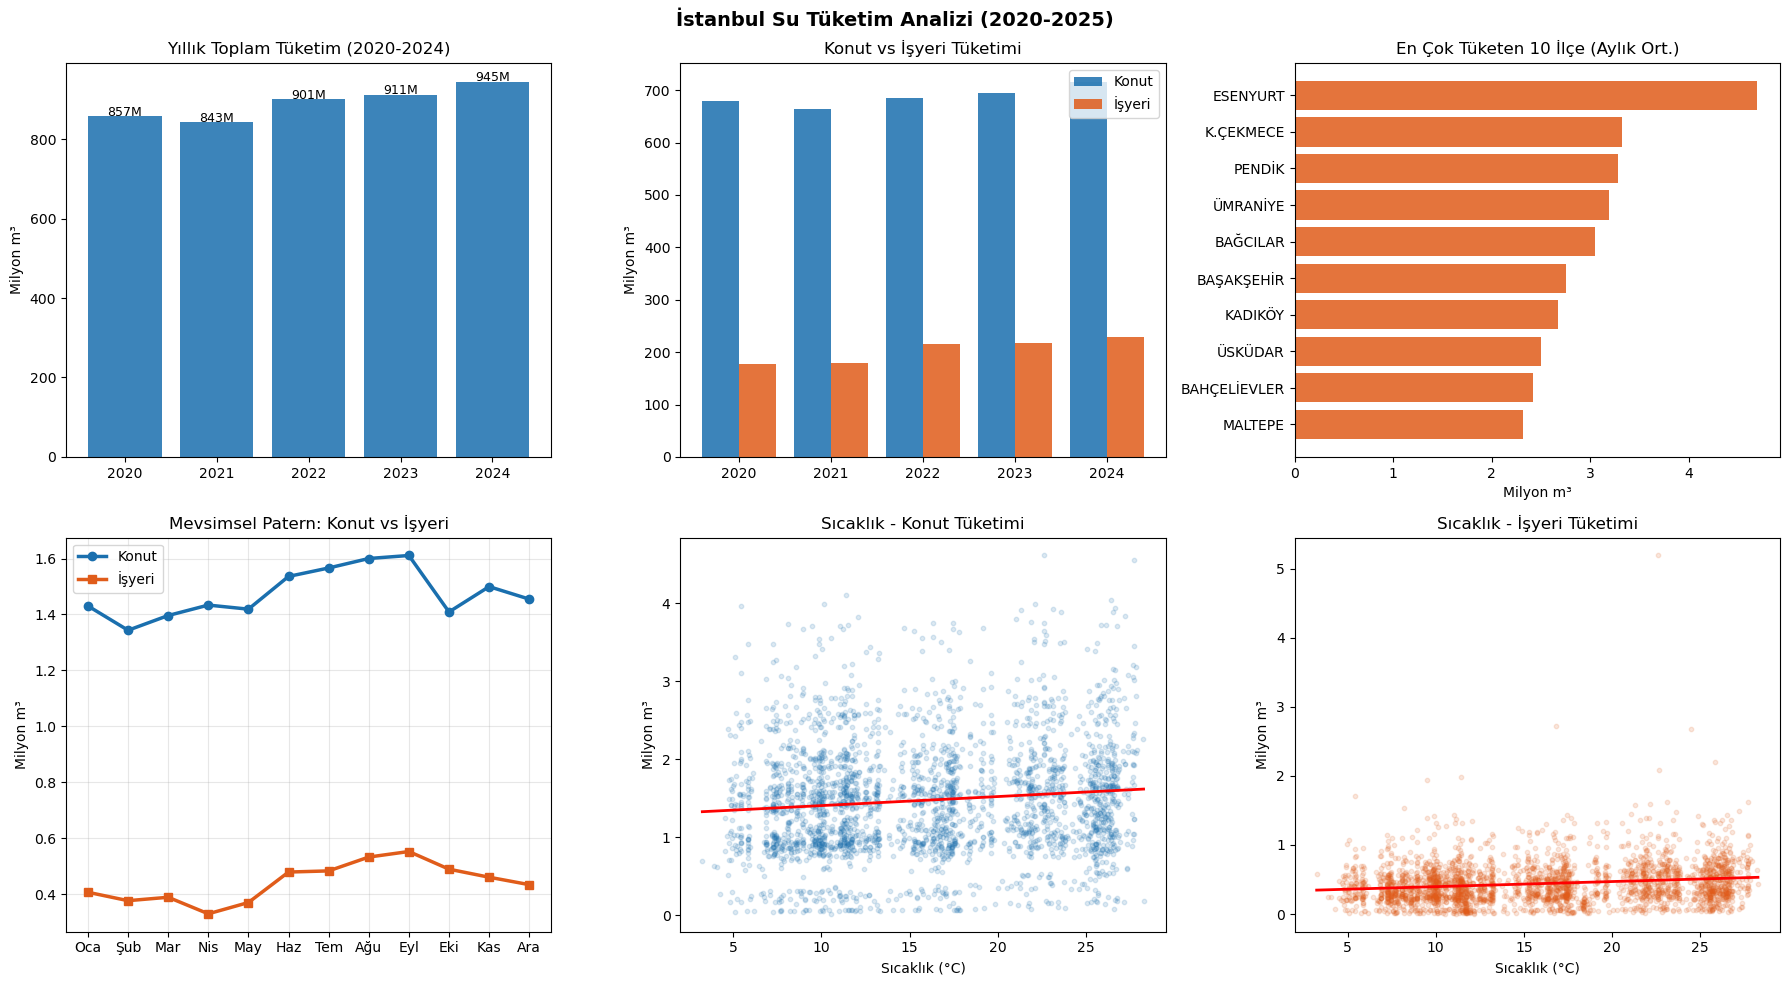

✅ Grafik kaydedildi: analiz.png


In [19]:
# ── AŞAMA 10: KEŞİFÇİ GRAFİKLER ───────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("İstanbul Su Tüketim Analizi (2020-2025)", fontsize=14, fontweight="bold")

# ─────────────────────────────────────────────
# Yıllık toplam tüketim
# ─────────────────────────────────────────────

ax1 = axes[0, 0]

yillik_tam = (
    df[df["yil"] < 2025]
    .groupby("yil")["su_tuketimi_m3"]
    .sum() / 1e6
)

ax1.bar(
    yillik_tam.index,
    yillik_tam.values,
    color="#1a6fae",
    alpha=0.85
)

ax1.set_title("Yıllık Toplam Tüketim (2020-2024)")
ax1.set_ylabel("Milyon m³")
ax1.set_xticks(yillik_tam.index)

for i, v in enumerate(yillik_tam.values):
    ax1.text(
        yillik_tam.index[i],
        v + 1,
        f"{v:.0f}M",
        ha="center",
        fontsize=9
    )

# ─────────────────────────────────────────────
# Konut vs işyeri
# ─────────────────────────────────────────────

ax2 = axes[0, 1]

yillik_konut = (
    df[df["yil"] < 2025]
    .groupby("yil")["konut_m3"]
    .sum() / 1e6
)

yillik_isyeri = (
    df[df["yil"] < 2025]
    .groupby("yil")["isyeri_m3"]
    .sum() / 1e6
)

x = np.arange(len(yillik_konut))

ax2.bar(
    x - 0.2,
    yillik_konut.values,
    width=0.4,
    label="Konut",
    color="#1a6fae",
    alpha=0.85
)

ax2.bar(
    x + 0.2,
    yillik_isyeri.values,
    width=0.4,
    label="İşyeri",
    color="#e05c1a",
    alpha=0.85
)

ax2.set_title("Konut vs İşyeri Tüketimi")
ax2.set_ylabel("Milyon m³")
ax2.set_xticks(x)
ax2.set_xticklabels(yillik_konut.index)
ax2.legend()

# ─────────────────────────────────────────────
# En çok tüketen ilçeler
# ─────────────────────────────────────────────

ax3 = axes[0, 2]

top10 = ilce_ort.head(10) / 1e6

ax3.barh(
    top10.index[::-1],
    top10.values[::-1],
    color="#e05c1a",
    alpha=0.85
)

ax3.set_title("En Çok Tüketen 10 İlçe (Aylık Ort.)")
ax3.set_xlabel("Milyon m³")

# ─────────────────────────────────────────────
# Mevsimsel patern
# ─────────────────────────────────────────────

ax4 = axes[1, 0]

aylik_konut = (
    df.groupby("ay")["konut_m3"]
    .mean() / 1e6
)

aylik_isyeri = (
    df.groupby("ay")["isyeri_m3"]
    .mean() / 1e6
)

ay_isimleri = [
    "Oca", "Şub", "Mar", "Nis",
    "May", "Haz", "Tem", "Ağu",
    "Eyl", "Eki", "Kas", "Ara"
]

ax4.plot(
    aylik_konut.index,
    aylik_konut.values,
    color="#1a6fae",
    linewidth=2.5,
    marker="o",
    label="Konut"
)

ax4.plot(
    aylik_isyeri.index,
    aylik_isyeri.values,
    color="#e05c1a",
    linewidth=2.5,
    marker="s",
    label="İşyeri"
)

ax4.set_title("Mevsimsel Patern: Konut vs İşyeri")
ax4.set_ylabel("Milyon m³")

ax4.set_xticks(range(1, 13))
ax4.set_xticklabels(ay_isimleri)

ax4.legend()
ax4.grid(True, alpha=0.3)

# ─────────────────────────────────────────────
# Sıcaklık - Konut
# ─────────────────────────────────────────────

ax5 = axes[1, 1]

x1 = pd.to_numeric(df["sicaklik_c"], errors="coerce")
y1 = pd.to_numeric(df["konut_m3"], errors="coerce") / 1e6

mask1 = np.isfinite(x1) & np.isfinite(y1)

x1 = x1[mask1]
y1 = y1[mask1]

ax5.scatter(
    x1,
    y1,
    alpha=0.15,
    color="#1a6fae",
    s=10
)

ax5.set_title("Sıcaklık - Konut Tüketimi")
ax5.set_xlabel("Sıcaklık (°C)")
ax5.set_ylabel("Milyon m³")

if len(x1) > 1:

    z = np.polyfit(x1, y1, 1)

    xp = np.linspace(
        x1.min(),
        x1.max(),
        100
    )

    ax5.plot(
        xp,
        np.poly1d(z)(xp),
        color="red",
        linewidth=2
    )

# ─────────────────────────────────────────────
# Sıcaklık - İşyeri
# ─────────────────────────────────────────────

ax6 = axes[1, 2]

x2 = pd.to_numeric(df["sicaklik_c"], errors="coerce")
y2 = pd.to_numeric(df["isyeri_m3"], errors="coerce") / 1e6

mask2 = np.isfinite(x2) & np.isfinite(y2)

x2 = x2[mask2]
y2 = y2[mask2]

ax6.scatter(
    x2,
    y2,
    alpha=0.15,
    color="#e05c1a",
    s=10
)

ax6.set_title("Sıcaklık - İşyeri Tüketimi")
ax6.set_xlabel("Sıcaklık (°C)")
ax6.set_ylabel("Milyon m³")

if len(x2) > 1:

    z2 = np.polyfit(x2, y2, 1)

    xp2 = np.linspace(
        x2.min(),
        x2.max(),
        100
    )

    ax6.plot(
        xp2,
        np.poly1d(z2)(xp2),
        color="red",
        linewidth=2
    )

# ─────────────────────────────────────────────

plt.tight_layout()

plt.savefig(
    "analiz.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("✅ Grafik kaydedildi: analiz.png")

In [20]:
# ── AŞAMA 11: CHRONOS MODELİNİ YÜKLE ──────────────────────
#
# Chronos, Amazon tarafından geliştirilmiş zero-shot zaman serisi modelidir.
# T5 mimarisini temel alır, Hugging Face üzerinden yüklenir.
#
# Mevcut modeller (küçükten büyüğe):
#   amazon/chronos-t5-tiny   (~8M  param) → çok hızlı, düşük doğruluk
#   amazon/chronos-t5-mini   (~20M param) → hızlı
#   amazon/chronos-t5-small  (~46M param) → dengeli
#   amazon/chronos-t5-base   (~200M param) → iyi performans
#   amazon/chronos-t5-large  (~710M param) → en iyi doğruluk, yavaş
#
# CPU için "small" veya "base" önerilir.
# GPU varsa "large" daha iyi sonuç verir.
#
# TimesFM'den farkı: Chronos olasılıksal tahmin üretir →
# quantile tahminleriyle güven aralığı hesaplanabilir!

CHRONOS_MODEL = "amazon/chronos-t5-small"   # GPU varsa "large" yap
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"

pipeline = ChronosPipeline.from_pretrained(
    CHRONOS_MODEL,
    device_map = DEVICE,
    torch_dtype= torch.bfloat16,   # bellek tasarrufu; float32 de kullanılabilir
)

print(f"✅ Chronos modeli yüklendi: {CHRONOS_MODEL}")
print(f"   Cihaz   : {DEVICE}")

`torch_dtype` is deprecated! Use `dtype` instead!


✅ Chronos modeli yüklendi: amazon/chronos-t5-small
   Cihaz   : cpu


In [21]:
# ── AŞAMA 12: CHRONOS FORMATINA ÇEVİR ──────────────────────
# TimesFM ile aynı strateji: konut ve işyerini AYRI AYRI tahmin et, sonra topla
# Bağlam: 2020-01 → 2024-12  |  Validasyon (gerçek): 2025-01 → 2025-10
#
# NOT: Chronos da TimesFM gibi exogenous değişken desteklemez.
# Sadece geçmiş seri (y) kullanılır.

def chronos_hazirla(df, hedef_col, context_bitis="2024-12-01"):
    df_fmt = df[["ilce", "tarih", hedef_col,
                 "sicaklik_c", "konut_abone", "isyeri_abone"]].copy()
    df_fmt = df_fmt.rename(columns={
        "ilce"    : "unique_id",
        "tarih"   : "ds",
        hedef_col : "y"
    })
    df_ctx = df_fmt[df_fmt["ds"] <= context_bitis].copy()
    df_val = df_fmt[df_fmt["ds"] >  context_bitis].copy()
    return df_ctx, df_val

df_ctx_konut,  df_val_konut  = chronos_hazirla(df, "konut_m3")
df_ctx_isyeri, df_val_isyeri = chronos_hazirla(df, "isyeri_m3")

print(f"✅ Konut   bağlam: {df_ctx_konut['ds'].min().strftime('%Y-%m')} → {df_ctx_konut['ds'].max().strftime('%Y-%m')}")
print(f"✅ İşyeri  bağlam: {df_ctx_isyeri['ds'].min().strftime('%Y-%m')} → {df_ctx_isyeri['ds'].max().strftime('%Y-%m')}")

✅ Konut   bağlam: 2020-01 → 2024-12
✅ İşyeri  bağlam: 2020-01 → 2024-12


In [23]:
# ── AŞAMA 13: EKSİK TARİHLERİ DOLDUR ──────────────────────
def tarihleri_tamamla(df_in, baslangic, bitis):
    tam_tarih = pd.date_range(start=baslangic, end=bitis, freq="MS")
    sonuc = []
    for ilce in df_in["unique_id"].unique():
        ilce_df = df_in[df_in["unique_id"] == ilce].set_index("ds")
        ilce_df = ilce_df.reindex(tam_tarih)
        ilce_df["unique_id"] = ilce
        ilce_df.index.name = "ds"
        ilce_df = ilce_df.reset_index()
        for col in ["y", "sicaklik_c", "konut_abone", "isyeri_abone"]:
            ilce_df[col] = ilce_df[col].interpolate(method="linear").ffill().bfill()
        sonuc.append(ilce_df)
    return pd.concat(sonuc).reset_index(drop=True)

# Bağlam: 2020-01 → 2024-12 (eğitim verisi)
df_ctx_konut_tam  = tarihleri_tamamla(df_ctx_konut,  "2020-01-01", "2024-12-01")
df_ctx_isyeri_tam = tarihleri_tamamla(df_ctx_isyeri, "2020-01-01", "2024-12-01")

# Validasyon: 2025-01 → 2025-12 (gerçek değerlerle karşılaştırılacak)
df_val_konut_tam  = tarihleri_tamamla(df_val_konut,  "2025-01-01", "2025-12-01")
df_val_isyeri_tam = tarihleri_tamamla(df_val_isyeri, "2025-01-01", "2025-12-01")

print(f"✅ Konut   bağlam (tam): {df_ctx_konut_tam.shape[0]} satır")
print(f"✅ İşyeri  bağlam (tam): {df_ctx_isyeri_tam.shape[0]} satır")
print(f"✅ Konut   validasyon  : {df_val_konut_tam.shape[0]} satır")
print(f"✅ İşyeri  validasyon  : {df_val_isyeri_tam.shape[0]} satır")

✅ Konut   bağlam (tam): 2340 satır
✅ İşyeri  bağlam (tam): 2340 satır
✅ Konut   validasyon  : 468 satır
✅ İşyeri  validasyon  : 468 satır


In [26]:
# ── AŞAMA 14: CHRONOS TAHMİN FONKSİYONU ────────────────────
def chronos_tahmin_yap(pipeline, df_ctx, h=12, num_samples=20, etiket=""):
    sonuclar = []
    ilceler  = df_ctx["unique_id"].unique()

    print(f"⏳ {etiket} Chronos tahmini başlıyor — {len(ilceler)} ilçe...")

    for i, ilce in enumerate(ilceler):
        seri_np = (
            df_ctx[df_ctx["unique_id"] == ilce]
            .sort_values("ds")["y"]
            .values
            .astype(np.float32)
        )
        context = torch.tensor(seri_np)   # ← unsqueeze(0) kaldırıldı

        with torch.no_grad():
            forecast = pipeline.predict(
                context,            # ← keyword değil, pozisyonel argüman
                h,                  # ← prediction_length de pozisyonel
                num_samples = num_samples,
            )

        # forecast shape: (1, num_samples, h) → (num_samples, h)
        samples = forecast[0].numpy()   # ← squeeze yerine [0]

        q50  = np.quantile(samples, 0.50, axis=0)
        q10  = np.quantile(samples, 0.10, axis=0)
        q90  = np.quantile(samples, 0.90, axis=0)
        q025 = np.quantile(samples, 0.025, axis=0)
        q975 = np.quantile(samples, 0.975, axis=0)

        q50  = np.maximum(q50,  0)
        q10  = np.maximum(q10,  0)
        q90  = np.maximum(q90,  0)
        q025 = np.maximum(q025, 0)
        q975 = np.maximum(q975, 0)

        son_tarih = df_ctx[df_ctx["unique_id"] == ilce]["ds"].max()
        tahmin_tarihleri = pd.date_range(
            start   = son_tarih + pd.DateOffset(months=1),
            periods = h,
            freq    = "MS"
        )

        ilce_df = pd.DataFrame({
            "unique_id" : ilce,
            "ds"        : tahmin_tarihleri,
            "tahmin"    : q50,
            "lo_80"     : q10,
            "hi_80"     : q90,
            "lo_95"     : q025,
            "hi_95"     : q975,
        })
        sonuclar.append(ilce_df)

        if (i + 1) % 10 == 0 or (i + 1) == len(ilceler):
            print(f"   {i+1}/{len(ilceler)} ilçe tamamlandı")

    return pd.concat(sonuclar).reset_index(drop=True)

print("✅ Chronos tahmin fonksiyonu güncellendi")

✅ Chronos tahmin fonksiyonu güncellendi


In [27]:
# ── AŞAMA 15: CHRONOS TAHMİNİ — KONUT ─────────────────────
tahmin_konut_raw = chronos_tahmin_yap(
    pipeline    = pipeline,
    df_ctx      = df_ctx_konut_tam,
    h           = 12,
    num_samples = 20,
    etiket      = "Konut"
)

tahmin_konut = tahmin_konut_raw.rename(columns={
    "tahmin" : "konut_tahmin",
    "lo_80"  : "konut_lo_80",
    "hi_80"  : "konut_hi_80",
    "lo_95"  : "konut_lo_95",
    "hi_95"  : "konut_hi_95",
})
print(f"✅ Konut tahmini tamamlandı: {tahmin_konut.shape[0]} satır")

⏳ Konut Chronos tahmini başlıyor — 39 ilçe...
   10/39 ilçe tamamlandı
   20/39 ilçe tamamlandı
   30/39 ilçe tamamlandı
   39/39 ilçe tamamlandı
✅ Konut tahmini tamamlandı: 468 satır


In [28]:
# ── AŞAMA 16: CHRONOS TAHMİNİ — İŞYERİ ────────────────────
tahmin_isyeri_raw = chronos_tahmin_yap(
    pipeline    = pipeline,
    df_ctx      = df_ctx_isyeri_tam,
    h           = 12,
    num_samples = 20,
    etiket      = "İşyeri"
)

tahmin_isyeri = tahmin_isyeri_raw.rename(columns={
    "tahmin" : "isyeri_tahmin",
    "lo_80"  : "isyeri_lo_80",
    "hi_80"  : "isyeri_hi_80",
    "lo_95"  : "isyeri_lo_95",
    "hi_95"  : "isyeri_hi_95",
})
print(f"✅ İşyeri tahmini tamamlandı: {tahmin_isyeri.shape[0]} satır")

⏳ İşyeri Chronos tahmini başlıyor — 39 ilçe...
   10/39 ilçe tamamlandı
   20/39 ilçe tamamlandı
   30/39 ilçe tamamlandı
   39/39 ilçe tamamlandı
✅ İşyeri tahmini tamamlandı: 468 satır


In [29]:
# ── AŞAMA 17: TAHMİNLERİ BİRLEŞTİR ────────────────────────
# Konut + işyeri tahminlerini ve güven aralıklarını topla

tahminler = tahmin_konut.merge(tahmin_isyeri, on=["unique_id", "ds"], how="inner")

tahminler["toplam_tahmin"] = tahminler["konut_tahmin"] + tahminler["isyeri_tahmin"]
tahminler["toplam_lo_80"]  = tahminler["konut_lo_80"]  + tahminler["isyeri_lo_80"]
tahminler["toplam_hi_80"]  = tahminler["konut_hi_80"]  + tahminler["isyeri_hi_80"]
tahminler["toplam_lo_95"]  = tahminler["konut_lo_95"]  + tahminler["isyeri_lo_95"]
tahminler["toplam_hi_95"]  = tahminler["konut_hi_95"]  + tahminler["isyeri_hi_95"]

print(f"✅ Tahminler birleştirildi: {tahminler.shape[0]} satır")
print(tahminler.head())

✅ Tahminler birleştirildi: 468 satır
  unique_id         ds  konut_tahmin   konut_lo_80   konut_hi_80  \
0    ADALAR 2025-01-01  60567.308594  47320.414062  64534.269531   
1    ADALAR 2025-02-01  53129.203125  49587.304688  63755.082031   
2    ADALAR 2025-03-01  60213.140625  48241.316406  66659.468750   
3    ADALAR 2025-04-01  59150.531250  52137.503906  64817.625000   
4    ADALAR 2025-05-01  61629.914062  51499.914062  72468.265625   

    konut_lo_95   konut_hi_95  isyeri_tahmin  isyeri_lo_80  isyeri_hi_80  \
0  42698.156250  67775.156250   19773.833984  16913.480469  21415.439453   
1  46240.144531  65986.507812   19276.378906  16614.990234  22460.093750   
2  40643.832031  68784.593750   18530.199219  14849.013672  21639.279297   
3  48843.496094  68005.414062   18903.296875  15545.462891  22907.802734   
4  48099.640625  75868.484375   19525.107422  16565.246094  24201.171875   

   isyeri_lo_95  isyeri_hi_95  toplam_tahmin  toplam_lo_80  toplam_hi_80  \
0  15738.235352  2268

In [30]:
# ── AŞAMA 18: PERFORMANS DEĞERLENDİRMESİ ───────────────────
gercek = df_val_konut_tam[["unique_id", "ds", "y"]].rename(columns={"y": "konut_gercek"})
gercek = gercek.merge(
    df_val_isyeri_tam[["unique_id", "ds", "y"]].rename(columns={"y": "isyeri_gercek"}),
    on=["unique_id", "ds"]
)
gercek["toplam_gercek"] = gercek["konut_gercek"] + gercek["isyeri_gercek"]

karsilastirma = tahminler.merge(gercek, on=["unique_id", "ds"], how="inner")

def mape_hesapla(gercek, tahmin):
    return (gercek - tahmin).abs() / gercek.abs() * 100

karsilastirma["mape_konut"]  = mape_hesapla(karsilastirma["konut_gercek"],  karsilastirma["konut_tahmin"])
karsilastirma["mape_isyeri"] = mape_hesapla(karsilastirma["isyeri_gercek"], karsilastirma["isyeri_tahmin"])
karsilastirma["mape_toplam"] = mape_hesapla(karsilastirma["toplam_gercek"], karsilastirma["toplam_tahmin"])

karsilastirma["abs_konut"]  = (karsilastirma["konut_gercek"]  - karsilastirma["konut_tahmin"]).abs()
karsilastirma["abs_isyeri"] = (karsilastirma["isyeri_gercek"] - karsilastirma["isyeri_tahmin"]).abs()
karsilastirma["abs_toplam"] = (karsilastirma["toplam_gercek"] - karsilastirma["toplam_tahmin"]).abs()

metrikler = (
    karsilastirma
    .groupby("unique_id")
    .agg(
        MAPE_Konut   = ("mape_konut",  "mean"),
        MAPE_Isyeri  = ("mape_isyeri", "mean"),
        MAPE_Toplam  = ("mape_toplam", "mean"),
        MAE_Konut    = ("abs_konut",   "mean"),
        MAE_Isyeri   = ("abs_isyeri",  "mean"),
        MAE_Toplam   = ("abs_toplam",  "mean"),
        RMSE_Konut   = ("abs_konut",   lambda x: np.sqrt((x**2).mean())),
        RMSE_Isyeri  = ("abs_isyeri",  lambda x: np.sqrt((x**2).mean())),
        RMSE_Toplam  = ("abs_toplam",  lambda x: np.sqrt((x**2).mean())),
    )
    .reset_index()
    .sort_values("MAPE_Toplam")
)

print("\n📊 İLÇE BAZLI PERFORMANS:")
print(metrikler.to_string(index=False))
print(f"\n🎯 Ort. MAPE  Konut  : {metrikler['MAPE_Konut'].mean():.2f}%")
print(f"🎯 Ort. MAPE  İşyeri : {metrikler['MAPE_Isyeri'].mean():.2f}%")
print(f"🎯 Ort. MAPE  Toplam : {metrikler['MAPE_Toplam'].mean():.2f}%")
print(f"🎯 Ort. MAE   Toplam : {metrikler['MAE_Toplam'].mean():,.0f} m³")
print(f"🎯 Ort. RMSE  Toplam : {metrikler['RMSE_Toplam'].mean():,.0f} m³")


📊 İLÇE BAZLI PERFORMANS:
   unique_id  MAPE_Konut  MAPE_Isyeri  MAPE_Toplam     MAE_Konut    MAE_Isyeri    MAE_Toplam    RMSE_Konut   RMSE_Isyeri   RMSE_Toplam
    BAĞCILAR    6.419718    10.322665     6.574378 129480.887500  69033.121875 176702.912500 242097.881564  99774.050244 299090.493940
  BAYRAMPAŞA    6.922968    12.718287     6.671486  51267.340625  43466.946354  77141.539583  89914.468293  67504.572384 107804.610048
BAHÇELİEVLER    8.019852     8.204522     6.708973 132781.206250  36487.048438 135474.429167 214989.943199  54396.897484 244452.057952
   KAĞITHANE    7.547838    16.375432     7.089720  98985.920833  63331.232812 124896.770833 178614.591635  83833.685197 185524.049328
     BEYOĞLU    8.873334     9.848485     7.112285  63137.658333  59453.209896  93392.518750  84884.290132  95816.755139 140168.958042
    G.O.PAŞA    6.862541    10.792673     7.121963  86069.160417  21968.772396 103220.797917 166619.102704  37153.005713 199336.871130
 ZEYTİNBURNU    6.377863    1

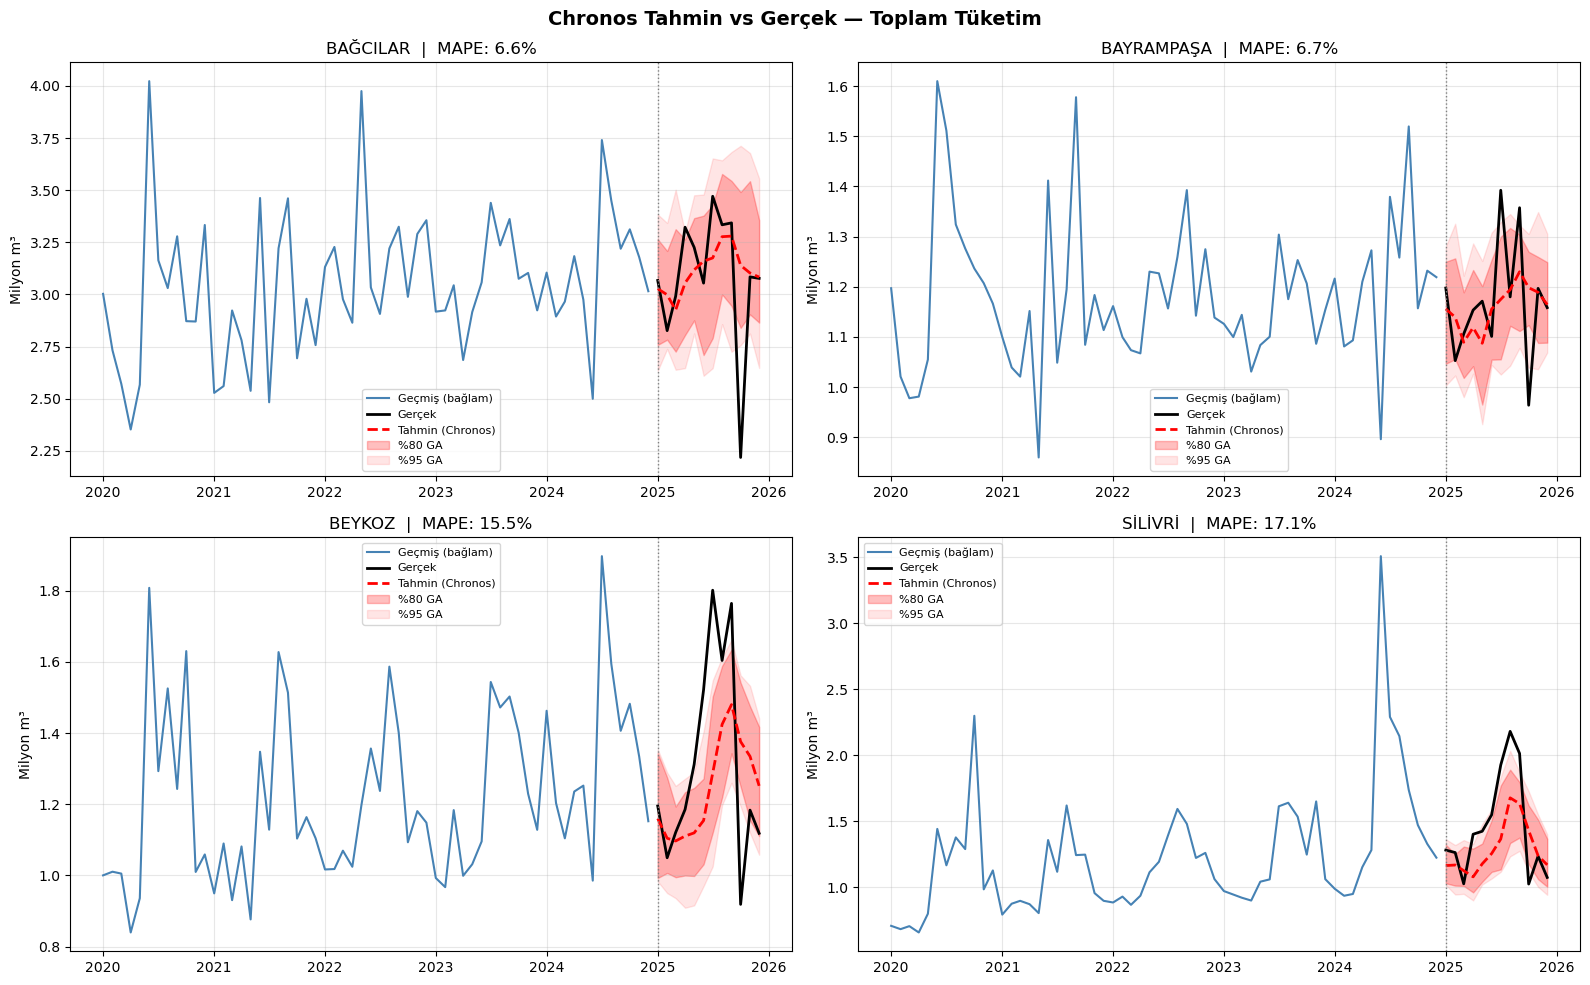

✅ Tahmin grafikleri kaydedildi: tahmin_grafikleri_chronos.png


In [31]:
# ── AŞAMA 19: TAHMİN GRAFİKLERİ ────────────────────────────
# TimeGPT gibi güven aralıkları var — fill_between kullanıyoruz

en_iyi  = metrikler.head(2)["unique_id"].tolist()
en_kotu = metrikler.tail(2)["unique_id"].tolist()
gosterilecek = en_iyi + en_kotu

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Chronos Tahmin vs Gerçek — Toplam Tüketim", fontsize=14, fontweight="bold")

for ax, ilce in zip(axes.flatten(), gosterilecek):
    gecmis        = df_ctx_konut_tam[df_ctx_konut_tam["unique_id"] == ilce].copy()
    gecmis_isyeri = df_ctx_isyeri_tam[df_ctx_isyeri_tam["unique_id"] == ilce].copy()
    gecmis["toplam"] = gecmis["y"].values + gecmis_isyeri["y"].values

    k        = karsilastirma[karsilastirma["unique_id"] == ilce]
    mape_val = metrikler[metrikler["unique_id"] == ilce]["MAPE_Toplam"].values[0]

    ax.plot(gecmis["ds"], gecmis["toplam"] / 1e6,
            color="steelblue", linewidth=1.5, label="Geçmiş (bağlam)")
    ax.plot(k["ds"], k["toplam_gercek"] / 1e6,
            color="black", linewidth=2, label="Gerçek")
    ax.plot(k["ds"], k["toplam_tahmin"] / 1e6,
            color="red", linewidth=2, linestyle="--", label="Tahmin (Chronos)")
    # %80 güven aralığı
    ax.fill_between(k["ds"],
                    k["toplam_lo_80"] / 1e6,
                    k["toplam_hi_80"] / 1e6,
                    alpha=0.25, color="red", label="%80 GA")
    # %95 güven aralığı
    ax.fill_between(k["ds"],
                    k["toplam_lo_95"] / 1e6,
                    k["toplam_hi_95"] / 1e6,
                    alpha=0.10, color="red", label="%95 GA")
    ax.axvline(pd.Timestamp("2025-01-01"), color="gray", linestyle=":", linewidth=1)
    ax.set_title(f"{ilce}  |  MAPE: {mape_val:.1f}%")
    ax.set_ylabel("Milyon m³")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("tahmin_grafikleri_chronos.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Tahmin grafikleri kaydedildi: tahmin_grafikleri_chronos.png")

In [32]:
# ── AŞAMA 20: SONUÇLARI EXCEL'E KAYDET ─────────────────────
CIKTI_DOSYASI = r"C:\Users\mynet\OneDrive\Masaüstü\istanbul_su_tahmini_chronos.xlsx"

with pd.ExcelWriter(CIKTI_DOSYASI, engine="openpyxl") as writer:
    karsilastirma.to_excel(writer, sheet_name="Tahmin vs Gerçek",   index=False)
    metrikler.to_excel(    writer, sheet_name="Performans",          index=False)
    tahminler.to_excel(    writer, sheet_name="Tahminler",           index=False)
    df_ctx_konut_tam.to_excel( writer, sheet_name="Bağlam Konut",   index=False)
    df_ctx_isyeri_tam.to_excel(writer, sheet_name="Bağlam İşyeri",  index=False)
    df.to_excel(           writer, sheet_name="Ham Veri",            index=False)

print(f"✅ Excel kaydedildi: {CIKTI_DOSYASI}")
print("\n🎉 Tüm işlem tamamlandı! (Chronos)")

✅ Excel kaydedildi: C:\Users\mynet\OneDrive\Masaüstü\istanbul_su_tahmini_chronos.xlsx

🎉 Tüm işlem tamamlandı! (Chronos)
